In [64]:
import torch
import torch.nn.functional as F

from torch_geometric.loader import DataLoader
from torch_geometric.data import Data

from dummy_data.builders import build_structured_data

NUM_GENES   = 64
NUM_CLASSES = 10
EMB_DIM     = 768

# ── Stage 1: Train backbone ───────────────────────────────────
data_list = build_structured_data(
    num_genes=NUM_GENES,
    num_classes=NUM_CLASSES,
    samples_per_class=20,
    noise_std=0.1,
)

In [65]:
loader    = DataLoader(data_list, batch_size=8, shuffle=True)


In [69]:
for batch in loader:
    print(batch.batch)
    break

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
        3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
        4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

In [ ]:
from Model.model import TissueClassificationPipeline
from Model.wrappers import build_explainer
from Model.embeddings import BioBERTEmbeddings

model = TissueClassificationPipeline(
    num_genes=NUM_GENES, gat_hidden=64, emb_dim=EMB_DIM,
    gat_heads=4, dropout=0.1, temperature=0.07,
)
label_emb, label_names = build_label_embeddings(NUM_CLASSES, EMB_DIM)
model.set_label_embeddings(label_emb, label_names)

loader    = DataLoader(data_list, batch_size=8, shuffle=True)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

for batch in loader:
    print(batch)

DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 1392], y=[8], batch=[512], ptr=[9])
DataBatch(x=[512, 64], edge_index=[2, 

In [ ]:
import wandb

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="yoyo458",
    # Set the wandb project where this run will be logged.
    project="my-awesome-project",
    # Track hyperparameters and run metadata.
    config={
        "learning_rate": 0.01,
        "architecture": "GNN",
        "dataset": "graph-test-dataset",
        "epochs": 20,
    },
)

print("=== Stage 1: Training backbone ===")
model.train()
for epoch in range(20):
    total_loss = 0.0
    total_acc = 0.0
    correct_conf = 0.0
    incorrect_conf = 0.0
    all_conf = 0.0
    num_batches = len(loader)

    for batch in loader:
        optimizer.zero_grad()
        out  = model(batch.x, batch.edge_index, batch.batch)
        loss, acc, conf = model.loss(out, batch.y.squeeze())
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_acc += acc
        correct_conf += conf['correct']
        incorrect_conf += conf['incorrect']
        all_conf += conf['all']


    avg_loss = total_loss / num_batches
    avg_acc = total_acc / num_batches
        
    print(f"  Epoch {epoch+1}  loss={loss.item():.4f}")
    run.log({"acc": acc, "loss": loss})

# ── Stage 2: Post-hoc GraphMask explanation ───────────────────
#
# GraphMaskExplainer freezes the backbone and trains gate networks.
# Each call to explainer() trains and then returns the edge_mask.
#
print("\n=== Stage 2: GraphMask explanation ===")
model.eval()

sample    = data_list[0]
batch_vec = torch.zeros(sample.x.size(0), dtype=torch.long)

# build_explainer pre-computes x_normed and bakes batch in as buffers,
# so the explainer call only needs x and edge_index (x is ignored internally
# in favour of the pre-normalized buffer, but required by the Explainer API).
explainer = build_explainer(model)


explanation = explainer(
    x=sample.x,
    edge_index=sample.edge_index,
    batch=batch_vec,
)


wandb: Loading settings from C:\Users\Yahya\.config\wandb\settings
wandb: [wandb.login()] Loaded credentials for http://localhost:8080 from C:\Users\Yahya\_netrc.
wandb: Currently logged in as: yoyo458 to http://localhost:8080. Use `wandb login --relogin` to force relogin


=== Stage 1: Training backbone ===
  Epoch 1  loss=2.3311
  Epoch 2  loss=2.0069
  Epoch 3  loss=2.0896
  Epoch 4  loss=1.5427
  Epoch 5  loss=1.4821
  Epoch 6  loss=1.4381
  Epoch 7  loss=1.2682
  Epoch 8  loss=1.2935
  Epoch 9  loss=1.0505
  Epoch 10  loss=1.1720
  Epoch 11  loss=1.3454
  Epoch 12  loss=0.9482
  Epoch 13  loss=0.7386
  Epoch 14  loss=0.8333
  Epoch 15  loss=1.3632
  Epoch 16  loss=1.0491
  Epoch 17  loss=0.8500
  Epoch 18  loss=1.2179
  Epoch 19  loss=0.9857
  Epoch 20  loss=1.3438

=== Stage 2: GraphMask explanation ===


In [5]:
print(f"\nEdge mask shape  : {explanation.edge_mask.shape}")
print(f"Edges retained   : {(explanation.edge_mask > 0.5).sum().item()} / {sample.edge_index.size(1)}")
print(f"Top-5 edge scores: {explanation.edge_mask.topk(5).values.tolist()}")

# ── Inference ────────────────────────────────────────────────
print("\n=== Inference ===")
results = model.predict(sample.x, sample.edge_index, batch_vec, confidence_threshold=0.5)
for r in results:
    flag = "" if r["reliable"] else "  ⚠ LOW CONFIDENCE — possible OOD"
    print(f"  → {r['tissue']}  conf={r['confidence']:.3f}{flag}")

# ── Adding an OOD tissue without retraining ───────────────────
#   new_emb   = torch.tensor(encoder.encode(["organoid proximal tubule"]))
#   all_emb   = torch.cat([label_emb, new_emb], dim=0)
#   all_names = label_names + ["organoid proximal tubule"]
#   model.set_label_embeddings(all_emb, all_names)
print("\nDone.")


Edge mask shape  : torch.Size([174])
Edges retained   : 1 / 174
Top-5 edge scores: [0.58185875415802, 0.3851759433746338, 0.3219519853591919, 0.21765992045402527, 0.15904664993286133]

=== Inference ===
  → tissue_0  conf=0.988

Done.


In [6]:
explanation

Explanation(edge_mask=[174], prediction=[1, 10], target=[1], x=[64, 64], edge_index=[2, 174], batch=[64])

In [7]:
from torch_geometric.data import Data
from typing import Optional, Union
import plotly.graph_objects as go
import networkx as nx
import numpy as np


def visualize_prototype_graph_interactive(
    sample:     Data,
    class_id:   int,
    num_genes:  int,
    edge_mask=  None,
    save_path:  Optional[str] = None,
    thresholds: Optional[list] = None,
) -> go.Figure:
    """
    Interactive Plotly visualization of the prototype graph with a slider
    to adjust the edge-weight threshold (top-X% of edges retained).

    TensorBoard compatibility
    ─────────────────────────
    Option A — HTML embed (recommended):
        writer.add_text("graph/explanation", iframe_html, global_step)
        where iframe_html = fig.to_html(full_html=False, include_plotlyjs='cdn')

    Option B — Static snapshot per threshold step:
        import plotly.io as pio
        img = pio.to_image(fig, format="png")
        writer.add_image("graph/explanation", img_tensor, global_step)

    Option C — Save standalone HTML and open via TensorBoard projector tab.

    Args:
        sample:      a single Data object
        class_id:    integer class label
        num_genes:   number of nodes
        edge_mask:   per-edge importance scores (optional)
        save_path:   if given, writes a self-contained HTML file here
        thresholds:  percentile cutoffs to expose on the slider,
                     e.g. [0, 10, 25, 50, 75, 90].
                     Defaults to [0, 10, 25, 50, 75, 90].

    Returns:
        plotly Figure (also saved to save_path if provided)
    """

    if thresholds is None:
        thresholds = [0, 10, 25, 50, 75, 90]

    edge_index = sample.edge_index.numpy()
    expr       = sample.x.mean(dim=1).numpy()          # [N]

    if edge_mask is not None:
        weights = edge_mask.detach().cpu().numpy().astype(float)
    else:
        weights = np.ones(edge_index.shape[1], dtype=float)

    hub_genes = {0, 1, 2}
    hi_start  = (class_id * 5) % num_genes
    lo_start  = (class_id * 5 + 5) % num_genes
    hi_block  = set(range(hi_start, min(hi_start + 5, num_genes)))
    lo_block  = set(range(lo_start, min(lo_start + 5, num_genes)))

    # ── Fixed circular layout (all nodes) ────────────────────────
    G_full = nx.DiGraph()
    G_full.add_nodes_from(range(num_genes))
    pos    = nx.circular_layout(G_full)   # {node: (x, y)}

    node_x = [pos[i][0] for i in range(num_genes)]
    node_y = [pos[i][1] for i in range(num_genes)]

    # Node colours: RdYlGn mapped to expression
    expr_norm = (expr - expr.min()) / max(expr.max() - expr.min(), 1e-8)

    def expr_to_rgb(v):
        # Manual RdYlGn: red(0) → yellow(0.5) → green(1)
        if v < 0.5:
            t = v * 2
            r, g, b = int(255), int(255 * t), 0
        else:
            t = (v - 0.5) * 2
            r, g, b = int(255 * (1 - t)), int(255), 0
        return f"rgb({r},{g},{b})"

    node_colors  = [expr_to_rgb(expr_norm[i]) for i in range(num_genes)]
    node_symbols = ["diamond" if i in hub_genes else "circle"
                    for i in range(num_genes)]
    node_sizes   = [14 if i in hub_genes else 10 for i in range(num_genes)]

    def node_label(i):
        tags = []
        if i in hub_genes: tags.append("hub")
        if i in hi_block:  tags.append("↑ hi")
        if i in lo_block:  tags.append("↓ lo")
        tag_str = f"  [{', '.join(tags)}]" if tags else ""
        return f"Gene {i}{tag_str}<br>expr={expr[i]:.2f}"

    node_hover = [node_label(i) for i in range(num_genes)]

    # ── Node trace (shared across all slider steps) ───────────────
    node_trace = go.Scatter(
        x=node_x, y=node_y,
        mode="markers+text",
        marker=dict(
            size=node_sizes,
            color=node_colors,
            symbol=node_symbols,
            line=dict(color="#1a1a2e", width=1.5),
        ),
        text=[str(i) if i in hub_genes else "" for i in range(num_genes)],
        textposition="middle center",
        textfont=dict(size=7, color="white", family="IBM Plex Mono"),
        hovertext=node_hover,
        hoverinfo="text",
        name="Genes",
    )

    # ── Bar chart traces (gene expression, one per category) ──────
    def bar_color(i):
        if i in hi_block:  return "#e05c5c"
        if i in lo_block:  return "#5b9bd5"
        if i in hub_genes: return "#c9a84c"
        return "#8ab4cc"

    bar_trace = go.Bar(
        x=list(range(num_genes)),
        y=expr.tolist(),
        marker_color=[bar_color(i) for i in range(num_genes)],
        hovertemplate="Gene %{x}<br>expr=%{y:.2f}<extra></extra>",
        name="Expression",
        xaxis="x2", yaxis="y2",
        showlegend=False,
    )

    # ── Build one set of edge traces per threshold step ───────────
    def build_edge_traces(pct_threshold):
        cutoff = np.percentile(weights, pct_threshold)
        keep   = weights >= cutoff

        retained = weights[keep]
        w_min, w_max = retained.min(), retained.max()
        if w_max > w_min:
            norm_w = (retained - w_min) / (w_max - w_min)
        else:
            norm_w = np.ones_like(retained)

        kept_idx = np.where(keep)[0]

        hub_ex, hub_ey, hub_ws   = [], [], []
        ring_ex, ring_ey, ring_ws = [], [], []

        for rank, i in enumerate(kept_idx):
            u, v = int(edge_index[0, i]), int(edge_index[1, i])
            x0, y0 = pos[u]
            x1, y1 = pos[v]
            nw = float(norm_w[rank])

            is_hub = (u in hub_genes or v in hub_genes)
            if is_hub:
                hub_ex  += [x0, x1, None]
                hub_ey  += [y0, y1, None]
                hub_ws.append(nw)
            else:
                ring_ex  += [x0, x1, None]
                ring_ey  += [y0, y1, None]
                ring_ws.append(nw)

        avg_ring_w = float(np.mean(ring_ws)) if ring_ws else 0.5
        avg_hub_w  = float(np.mean(hub_ws))  if hub_ws  else 0.5

        ring_trace = go.Scatter(
            x=ring_ex, y=ring_ey,
            mode="lines",
            line=dict(
                color="black",
                width=1.0 + 3.0 * avg_ring_w,
            ),
            opacity=0.7,
            hoverinfo="skip",
            name="Ring edges",
            showlegend=False,
        )
        hub_trace = go.Scatter(
            x=hub_ex, y=hub_ey,
            mode="lines",
            line=dict(
                color="black",
                width=2.0 + 3.0 * avg_hub_w,
            ),
            opacity=0.85,
            hoverinfo="skip",
            name="Hub edges",
            showlegend=False,
        )
        n_kept = int(keep.sum())
        return ring_trace, hub_trace, n_kept

    # ── Assemble frames for slider ────────────────────────────────
    # Trace order in each frame: [ring_edges, hub_edges, nodes, bar]
    # Nodes and bar are static; only edge traces change.
    all_frames = []
    slider_steps = []

    for pct in thresholds:
        ring_tr, hub_tr, n_kept = build_edge_traces(pct)
        frame = go.Frame(
            data=[ring_tr, hub_tr, node_trace, bar_trace],
            name=str(pct),
        )
        all_frames.append(frame)
        slider_steps.append(dict(
            method="animate",
            args=[[str(pct)], dict(
                mode="immediate",
                frame=dict(duration=0, redraw=True),
                transition=dict(duration=0),
            )],
            label=f"{100 - pct}%  ({n_kept} edges)",
        ))

    # Initial frame = first threshold
    init_ring, init_hub, init_n = build_edge_traces(thresholds[0])

    # ── Layout ───────────────────────────────────────────────────
    layout = go.Layout(
        title=dict(
            text=(
                f"Prototype graph — class {class_id} &nbsp;│&nbsp; "
                f"hi block: genes {hi_start}–{hi_start+4} &nbsp;│&nbsp; "
                f"lo block: genes {lo_start}–{lo_start+4}"
            ),
            font=dict(family="IBM Plex Mono", size=13, color="#1a1a2e"),
            x=0.01,
        ),
        paper_bgcolor="#f5f5f0",
        plot_bgcolor="#f5f5f0",
        font=dict(family="IBM Plex Mono", color="#1a1a2e"),

        # Left panel (graph)
        xaxis=dict(
            domain=[0, 0.58],
            showgrid=False, zeroline=False, showticklabels=False,
            scaleanchor="y",
        ),
        yaxis=dict(
            showgrid=False, zeroline=False, showticklabels=False,
        ),

        # Right panel (bar chart)
        xaxis2=dict(
            domain=[0.65, 1.0],
            title=dict(text="Gene index", font=dict(size=11)),
            showgrid=True, gridcolor="#ddd",
        ),
        yaxis2=dict(
            anchor="x2",
            title=dict(text="Mean expression [log2(TPM+1)]", font=dict(size=11)),
            range=[0, 4.5],
            showgrid=True, gridcolor="#ddd",
        ),

        # Reference lines on bar chart
        shapes=[
            dict(type="line", xref="x2", yref="y2",
                 x0=-1, x1=num_genes, y0=1.5, y1=1.5,
                 line=dict(color="grey", width=1, dash="dash")),
            dict(type="line", xref="x2", yref="y2",
                 x0=-1, x1=num_genes, y0=3.0, y1=3.0,
                 line=dict(color="#e05c5c", width=1, dash="dot")),
            dict(type="line", xref="x2", yref="y2",
                 x0=-1, x1=num_genes, y0=0.5, y1=0.5,
                 line=dict(color="#5b9bd5", width=1, dash="dot")),
        ],

        annotations=[
            dict(xref="x2", yref="y2", x=num_genes * 0.98, y=1.55,
                 text="background", showarrow=False,
                 font=dict(size=8, color="grey")),
            dict(xref="x2", yref="y2", x=num_genes * 0.98, y=3.05,
                 text="hi target", showarrow=False,
                 font=dict(size=8, color="#e05c5c")),
            dict(xref="x2", yref="y2", x=num_genes * 0.98, y=0.55,
                 text="lo target", showarrow=False,
                 font=dict(size=8, color="#5b9bd5")),
            # Legend annotations
            dict(xref="paper", yref="paper", x=0.0, y=-0.12,
                 text="◆ hub gene &nbsp;&nbsp; ● gene &nbsp;&nbsp; "
                      "<span style='color:#e05c5c'>■</span> hi block &nbsp;&nbsp; "
                      "<span style='color:#5b9bd5'>■</span> lo block &nbsp;&nbsp; "
                      "<span style='color:#c9a84c'>■</span> hub",
                 showarrow=False, font=dict(size=9), align="left"),
        ],

        sliders=[dict(
            active=0,
            currentvalue=dict(
                prefix="Edges retained: ",
                font=dict(size=11, family="IBM Plex Mono"),
                xanchor="left",
            ),
            pad=dict(t=50, b=10),
            steps=slider_steps,
            bgcolor="#ddd",
            activebgcolor="#1a1a2e",
            bordercolor="#aaa",
            font=dict(family="IBM Plex Mono", size=9),
        )],

        margin=dict(l=20, r=20, t=70, b=100),
        height=560,
    )

    fig = go.Figure(
        data=[init_ring, init_hub, node_trace, bar_trace],
        layout=layout,
        frames=all_frames,
    )

    if save_path:
        fig.write_html(
            save_path,
            full_html=True,
            include_plotlyjs="cdn",
            auto_play=False,
        )
        print(f"Saved interactive HTML to {save_path}")

    return fig

def add_graph_explanation_to_tensorboard(
    writer,
    fig,
    tag:         str = "graph/explanation",
    global_step: int = 0,
):
    html_str = fig.to_html(full_html=True, include_plotlyjs="cdn")
    
    # Write to a temp file and embed via iframe
    import tempfile, os
    with tempfile.NamedTemporaryFile(
        mode="w", suffix=".html", delete=False, encoding="utf-8"
    ) as f:
        f.write(html_str)
        tmp_path = f.name

    # TensorBoard Text tab supports a limited iframe markdown tag
    iframe_md = f'<iframe src="file://{tmp_path}" width="100%" height="600px"></iframe>'
    writer.add_text(tag, iframe_md, global_step=global_step)

In [ ]:
visualize_prototype_graph_interactive(
    sample=data_list[0],
    class_id=0,
    num_genes=NUM_GENES,
    edge_mask=explanation.edge_mask,
    save_path="./Dataset/result/prototype_graph_sample21.png",
)

In [8]:
with wandb.init(project="my-project") as run:
    fig = visualize_prototype_graph_interactive(
        sample=sample,
        class_id=0,
        num_genes=NUM_GENES,
        edge_mask=explanation.edge_mask,
        save_path="./Dataset/result/prototype_graph.html",  # saves the file
    )
    
    # Log the saved HTML file
    run.log({"prototype_graph": wandb.Html("./Dataset/result/prototype_graph.html")})

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


acc,▁▃▃▅▆▅▅▆▆▇▆▆█▅▃▇▇▆▇▃
loss,█▇▇▅▄▄▃▃▂▃▄▂▁▁▄▂▁▃▂▄
acc,0.25
loss,1.34377


Saved interactive HTML to ./Dataset/result/prototype_graph.html


In [7]:
from Dataset.TemplateBuild import GraphDataset, GraphSnapshot, DatasetBuilder
from Dataset.utils import GraphTraverse

graph_snapshot = GraphSnapshot('./Dataset/result/ML_Dataset/graph_snapshot.pkl')
graph_snapshot.graph.graph

Loading graph from ./Dataset/result/ML_Dataset/graph_snapshot.pkl...


{'pid_name': {'hsa00010': 'Glycolysis / Gluconeogenesis',
  'hsa00020': 'Citrate cycle (TCA cycle)',
  'hsa00030': 'Pentose phosphate pathway',
  'hsa00040': 'Pentose and glucuronate interconversions',
  'hsa00051': 'Fructose and mannose metabolism',
  'hsa00052': 'Galactose metabolism',
  'hsa00053': 'Ascorbate and aldarate metabolism',
  'hsa00061': 'Fatty acid biosynthesis',
  'hsa00062': 'Fatty acid elongation',
  'hsa00071': 'Fatty acid degradation',
  'hsa00100': 'Steroid biosynthesis',
  'hsa00120': 'Primary bile acid biosynthesis',
  'hsa00130': 'Ubiquinone and other terpenoid-quinone biosynthesis',
  'hsa00140': 'Steroid hormone biosynthesis',
  'hsa00190': 'Oxidative phosphorylation',
  'hsa00220': 'Arginine biosynthesis',
  'hsa00230': 'Purine metabolism',
  'hsa00232': 'Caffeine metabolism',
  'hsa00240': 'Pyrimidine metabolism',
  'hsa00250': 'Alanine, aspartate and glutamate metabolism',
  'hsa00260': 'Glycine, serine and threonine metabolism',
  'hsa00270': 'Cysteine and

In [8]:
ds = DatasetBuilder('./Dataset/result/', graph_snapshot=graph_snapshot)

In [19]:
from networkx.linalg import fiedler_vector
import numpy as np

G = ds.gs.graph
G_undirected = G.to_undirected()

components = sorted(nx.connected_components(G_undirected), key=len, reverse=True)

ordered_nodes = []
for component in components:
    subgraph = G_undirected.subgraph(component)
    nodes = list(subgraph.nodes())

    if len(nodes) == 1:
        ordered_nodes.extend(nodes)
    elif len(nodes) == 2:
        ordered_nodes.extend(nodes)
    else:
        fiedler = nx.fiedler_vector(subgraph)
        order = np.argsort(fiedler)
        ordered_nodes.extend([nodes[i] for i in order])


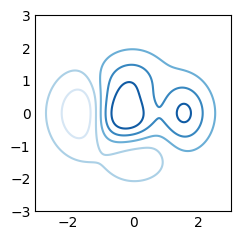

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery-nogrid')

# make data
X, Y = np.meshgrid(np.linspace(-3, 3, 256), np.linspace(-3, 3, 256))
Z = (1 - X/2 + X**5 + Y**3) * np.exp(-X**2 - Y**2)
levels = np.linspace(np.min(Z), np.max(Z), 7)

# plot
fig, ax = plt.subplots()

ax.contour(X, Y, Z, levels=levels)

plt.show()

In [31]:
axis = np.linspace(-50, 50, len(ordered_nodes))

In [54]:
ds.gs.graph.graph['pid_name']['hsa05165']

'Human papillomavirus infection'

In [52]:
G.edges(data=True)

OutEdgeDataView([('hsa:4799', 'hsa:7015', {'type': 'REPRESSION', 'pathways': ['hsa05165']}), ('hsa:5734', 'hsa:2778', {'type': 'ACTIVATION', 'pathways': ['hsa05165']}), ('hsa:10474', 'hsa:7157', {'type': 'ACTIVATION', 'pathways': ['hsa05165']}), ('hsa:6188', 'hsa:5970', {'type': 'ACTIVATION', 'pathways': ['hsa05130']}), ('hsa:7009', 'hsa:578', {'type': 'INHIBITION', 'pathways': ['hsa05130']}), ('hsa:7009', 'hsa:581', {'type': 'INHIBITION', 'pathways': ['hsa05130']}), ('hsa:10061', 'hsa:842', {'type': 'INHIBITION', 'pathways': ['hsa05130']}), ('hsa:1434', 'hsa:3836', {'type': 'ACTIVATION', 'pathways': ['hsa05132']}), ('hsa:391', 'hsa:63916', {'type': 'ACTIVATION', 'pathways': ['hsa05132', 'hsa05100']}), ('hsa:26084', 'hsa:391', {'type': 'ACTIVATION', 'pathways': ['hsa05132', 'hsa05100']}), ('hsa:4646', 'hsa:5286', {'type': 'ACTIVATION', 'pathways': ['hsa05132']}), ('hsa:112574', 'hsa:8976', {'type': 'ACTIVATION', 'pathways': ['hsa05132']}), ('hsa:112574', 'hsa:1785', {'type': 'ACTIVATIO

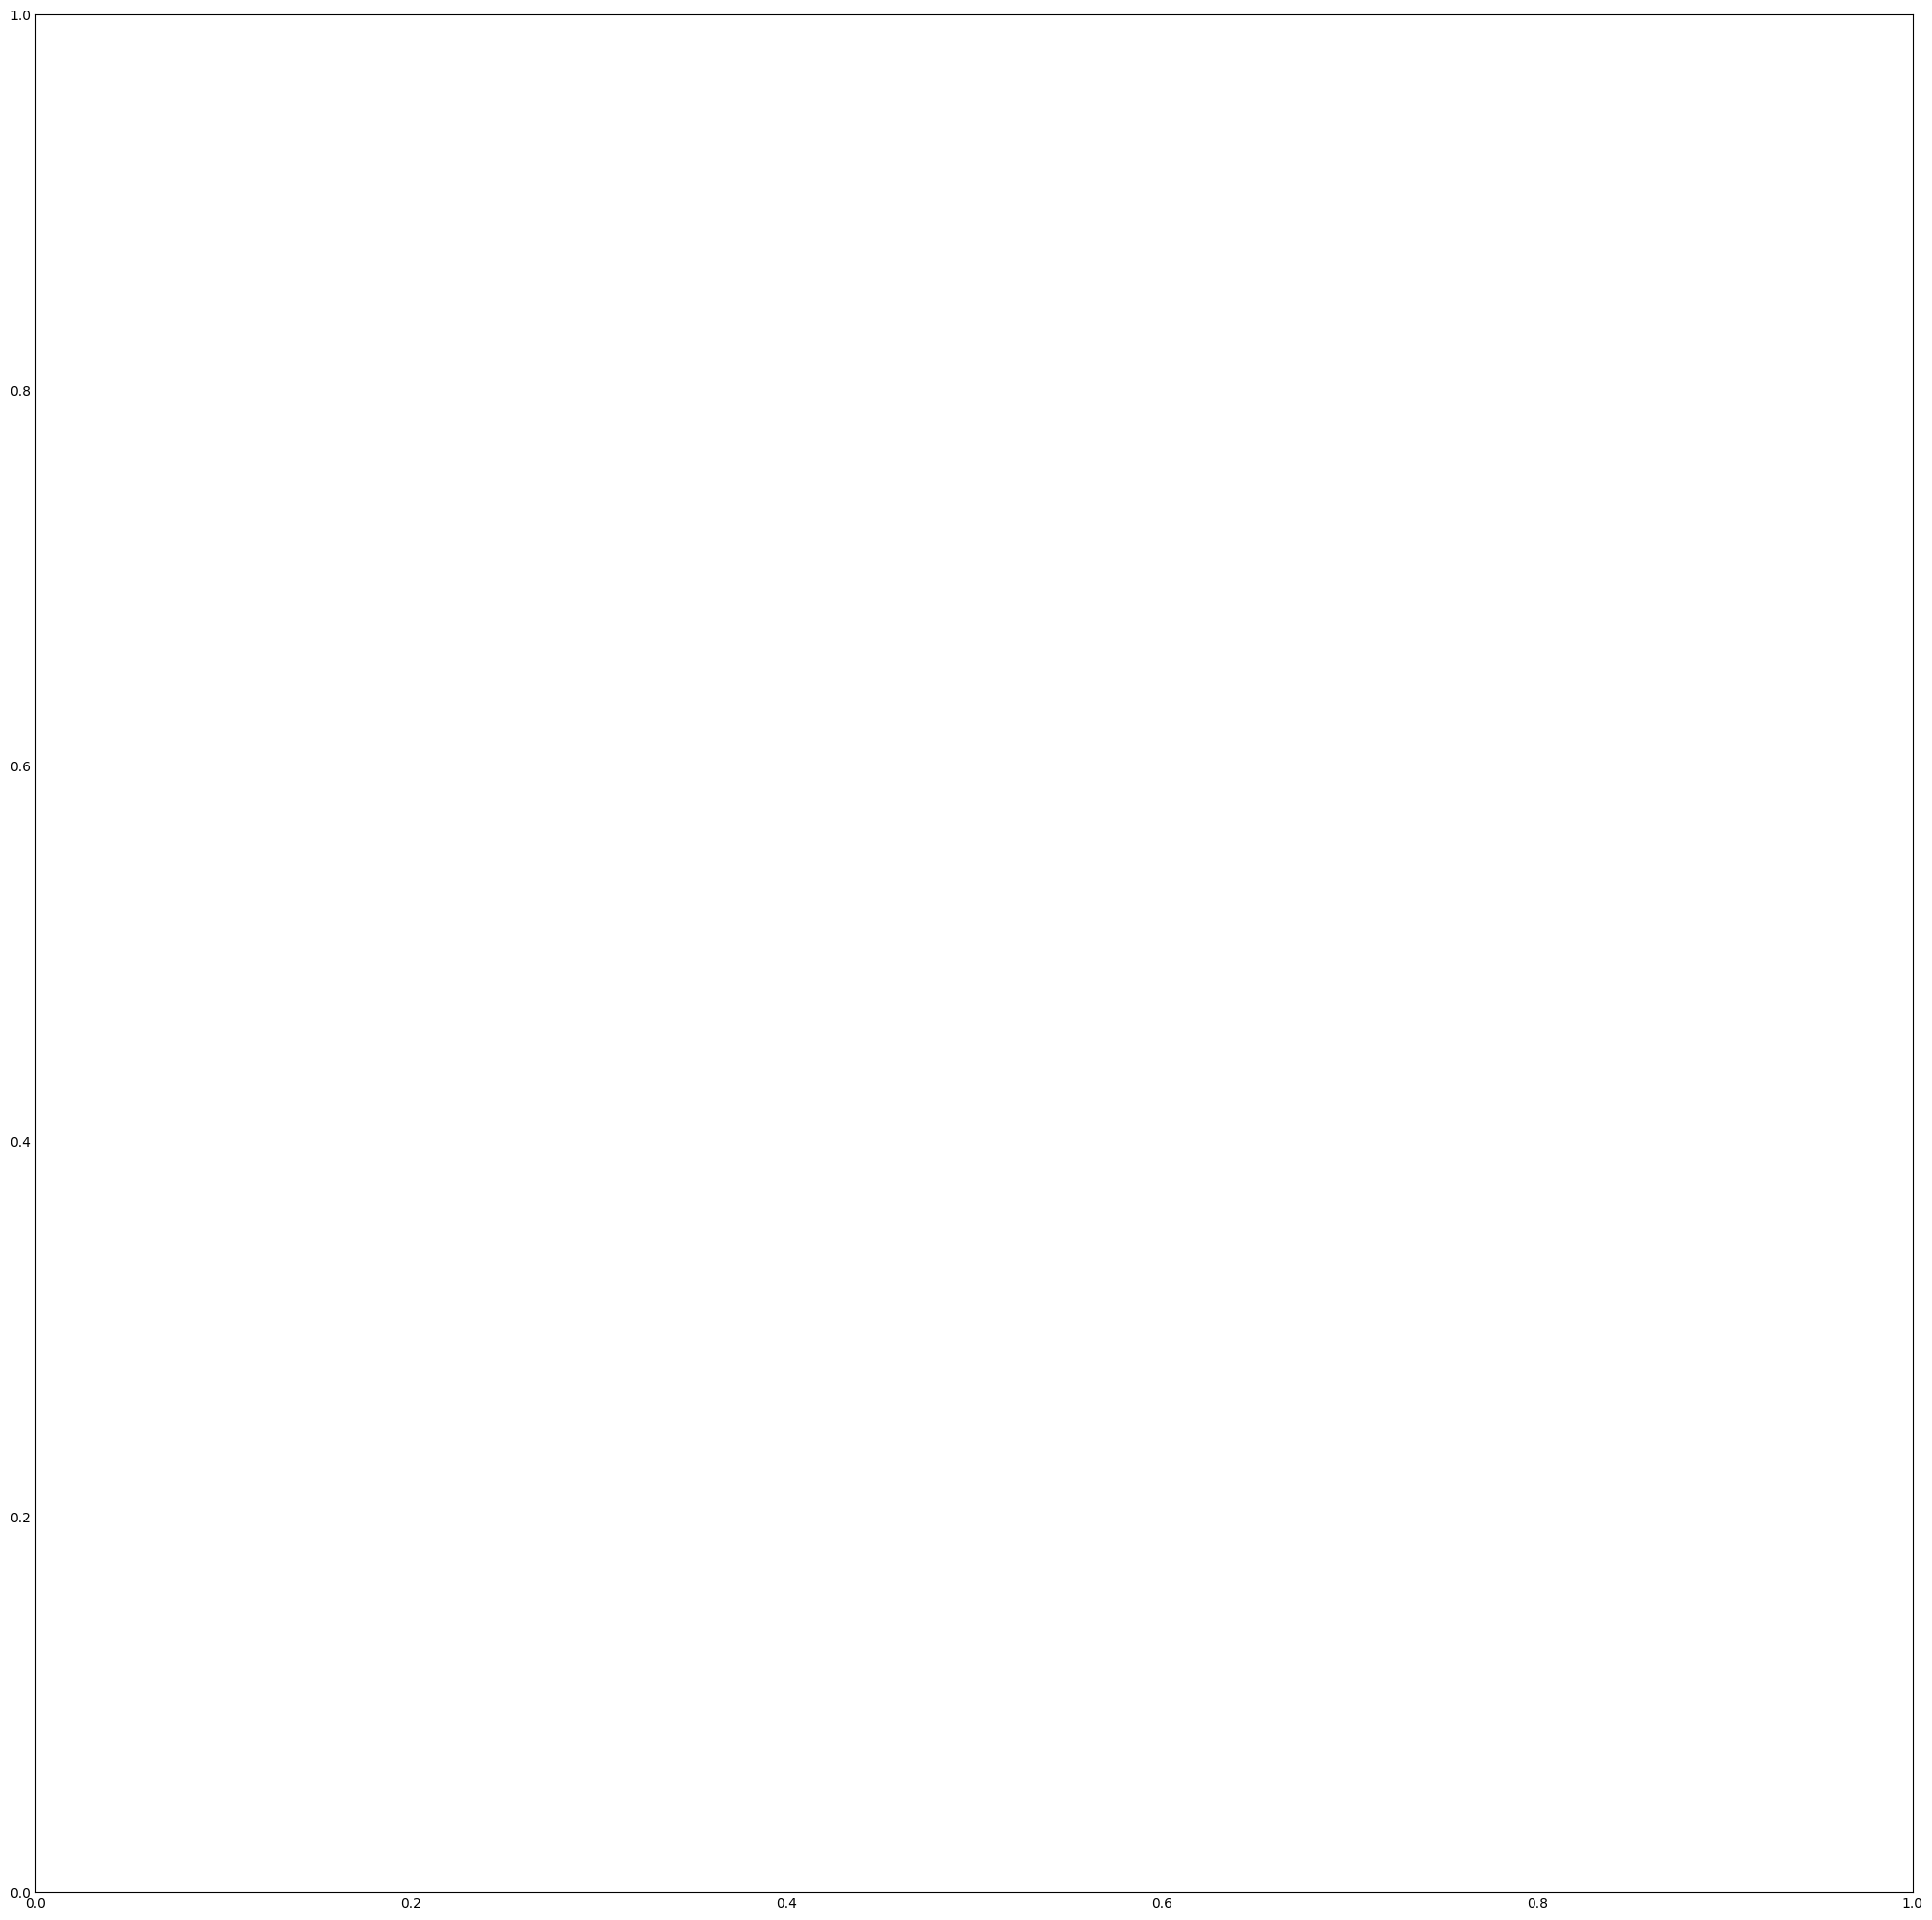

In [ ]:
import plotly.graph_objects as go
from collections import defaultdict
import plotly.express as px


def hex_to_rgba(hex_color, alpha):
    r, g, b = pc.hex_to_rgb(hex_color)
    return f'rgba({r},{g},{b},{alpha:.3f})'

# build pathway name lookup
pid_name = ds.gs.graph.graph['pid_name']

fig, ax = plt.subplots(figsize=(20,20))

# get all unique pathways and assign colors
all_pathways = set()
for u, v, data in G.edges(data=True):
    for p in data.get('pathways', []):
        all_pathways.add(p)

all_pathways = list(all_pathways)
palette = px.colors.qualitative.Plotly  # or Safe, D3, Light24 for more colors
pathway_color = {p: palette[i % len(palette)] for i, p in enumerate(all_pathways)}



ordered_pos = {node: i for i, node in enumerate(ordered_nodes)}
pos = {node: i for i, node in enumerate(G.nodes())}

# collect edge data
xs, ys, hover_texts, colors = [], [], [], []
edge_pathways = []

for u, v, data in G.edges(data=True):
    pu, pv = pos[u], pos[v]

    if pu >= pv:
        continue

    xs.append(axis[pu])
    ys.append(axis[pv])
    
    pathways = data.get('pathways', [])
    pathway_names = [pid_name.get(p, p) for p in pathways]
    edge_type = data.get('type', 'UNKNOWN')

    color = pathway_color.get(pathways[0], 'gray') if pathways else 'gray'
    colors.append(color)
    hover_texts.append(
        f"<b>{u} → {v}</b><br>"
        f"Type: {edge_type}<br>"
        f"Pathways:<br>" + "<br>".join(f"  • {n}" for n in pathway_names)
    )
    edge_pathways.append(pathways)

colors_with_alpha = [
    hex_to_rgba(pathway_color.get(pathways[0], '#888888'), alphas[i])
    if edge_pathways[i] else f'rgba(128,128,128,{alphas[i]:.3f})'
    for i, pathways in enumerate(edge_pathways)
]


# base scatter — all edges
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=xs,
    y=ys,
    mode='markers',
    marker=dict(size=3, color=colors, opacity=0.6),
    hovertext=hover_texts,
    hoverinfo='text',
    name='all edges',
    showlegend=True
))

# one trace per pathway for toggling
pathway_to_edges = defaultdict(list)
for i, pathways in enumerate(edge_pathways):
    for p in pathways:
        pathway_to_edges[p].append(i)

for pid in all_pathways:
    edge_indices = pathway_to_edges[pid]
    name = pid_name.get(pid, pid)
    color = pathway_color[pid]
    fig.add_trace(go.Scatter(
        x=[xs[i] for i in edge_indices],
        y=[ys[i] for i in edge_indices],
        mode='markers',
        marker=dict(size=10, color=color, opacity=0.9),
        hovertext=[hover_texts[i] for i in edge_indices],
        hoverinfo='text',
        name=name,
        visible='legendonly',
    ))

fig.update_layout(
    width=900,
    height=900,
    xaxis=dict(tickvals=list(range(len(ordered_nodes))), ticktext=ordered_nodes, tickangle=90, tickfont=dict(size=7)),
    yaxis=dict(tickvals=list(range(len(ordered_nodes))), ticktext=ordered_nodes, tickfont=dict(size=7)),
    legend=dict(itemclick='toggle', itemdoubleclick='toggleothers'),
    hovermode='closest',
)

fig.write_html('network_matrix.html')

In [ ]:


weights = np.array(1 for u, v in G.edges())